In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import mean_squared_error

In [2]:
data = pd.read_csv('varicelle.csv')

In [3]:
dates = pd.date_range(start='1931-01-01', periods=len(data), freq='ME')

In [4]:
data.index = dates
data = data["nb"]

<Axes: >

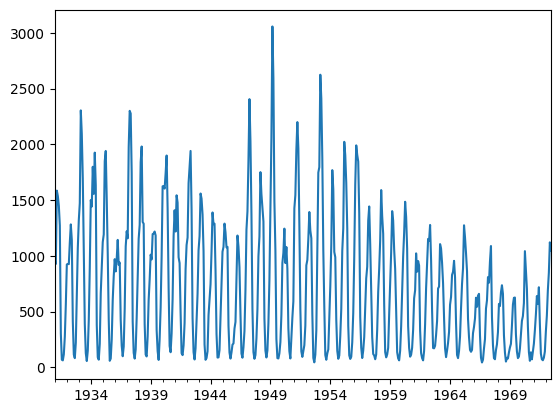

In [5]:
data.plot()

Tendance linéaire décroissante et présence de saisonalité

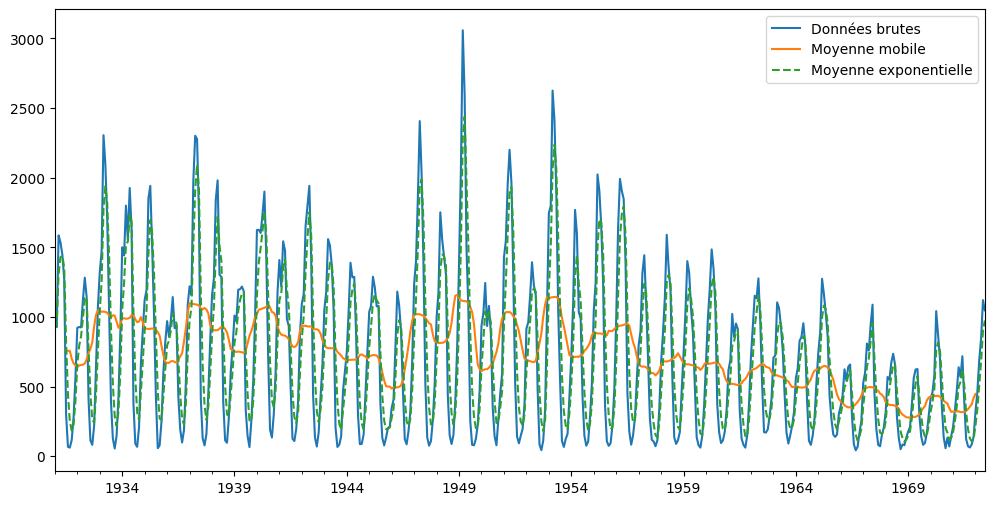

In [6]:
plt.figure(figsize=(12, 6))
data.plot(label='Données brutes')
data.rolling(window=12, center=True).mean().plot(label='Moyenne mobile')
data.ewm(alpha=0.5).mean().plot(label='Moyenne exponentielle', linestyle='--')
plt.legend()
plt.show()

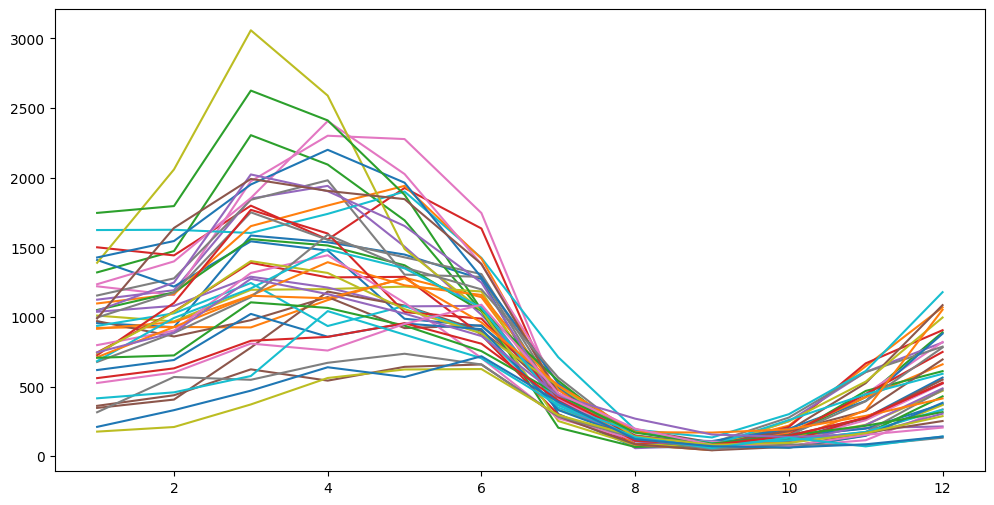

In [7]:
plt.figure(figsize=(12, 6))
année = range(1,13)
for i in range(1931, 1972):
    plt.plot(année,data[f'{i}'], label=f'Année{i}')
plt.show()

<Axes: >

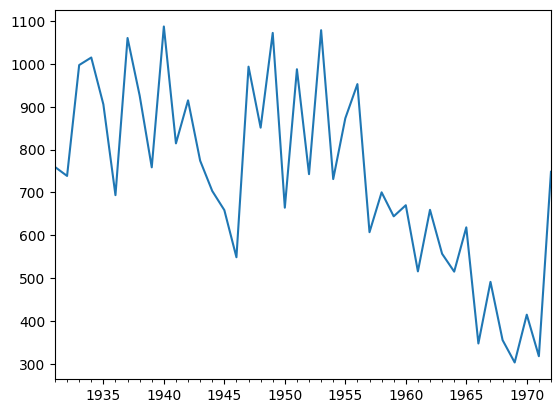

In [8]:
data.resample('YE').mean().plot()

In [9]:
agg = data.resample('YE').agg(['mean', 'std', 'min', 'max', 'sum'])
agg

,mean,std,min,max,sum
1931-12-31,759.416667,599.051744,62,1585,9113
1932-12-31,738.500000,428.926037,82,1282,8862
1933-12-31,997.166667,786.373938,56,2305,11966
1934-12-31,1014.750000,705.650586,68,1926,12177
1935-12-31,905.500000,648.238382,58,1941,10866
1936-12-31,693.666667,382.975037,99,1143,8324
1937-12-31,1060.250000,844.985651,78,2301,12723
1938-12-31,926.000000,645.218638,97,1981,11112
1939-12-31,758.583333,455.524764,66,1218,9103
1940-12-31,1087.166667,656.901796,135,1900,13046


In [10]:
agg.describe()

,mean,std,min,max,sum
count,42.000000,42.000000,42.000000,42.000000,42.000000
mean,732.595238,533.317297,85.928571,1535.404762,8684.261905
std,219.053931,202.232551,44.247305,548.786202,2710.840713
min,303.333333,199.942871,43.000000,626.000000,3640.000000
25%,610.083333,375.415025,66.250000,1152.750000,6834.000000
50%,734.875000,501.605885,78.000000,1422.000000,8608.000000
75%,912.500000,654.735943,88.750000,1937.250000,10950.000000
max,1087.166667,1049.052112,320.000000,3058.000000,13046.000000


<Axes: >

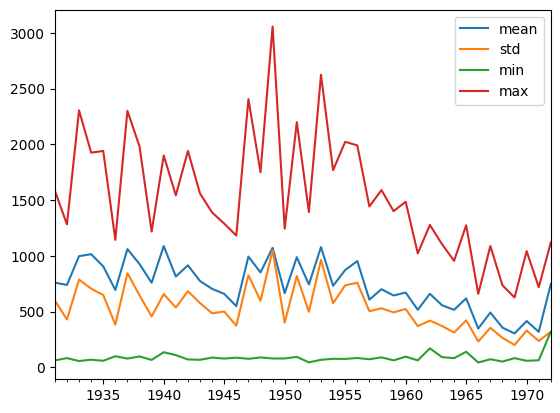

In [11]:
agg[['mean', 'std', 'min', 'max']].plot()

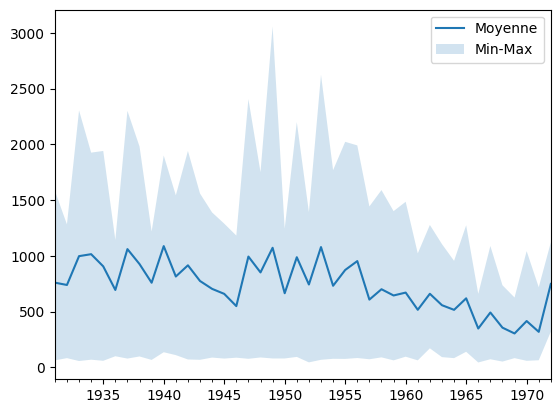

In [12]:
agg['mean'].plot(label='Moyenne')
plt.fill_between(agg.index, agg['min'], agg['max'], alpha=0.2, label='Min-Max')
plt.legend()
plt.show()

In [13]:
model = sm.OLS(agg['std'], agg['mean'])
res = model.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                    std   R-squared (uncentered):                   0.979
Model:                            OLS   Adj. R-squared (uncentered):              0.978
Method:                 Least Squares   F-statistic:                              1893.
Date:                Sat, 10 Jan 2026   Prob (F-statistic):                    6.13e-36
Time:                        22:44:55   Log-Likelihood:                         -245.15
No. Observations:                  42   AIC:                                      492.3
Df Residuals:                      41   BIC:                                      494.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
mean           0.7376      0.017     43.508      0.000       0.703       0.772
==============================================================================
Omnibus:                        6.487   Durbin-Watson:                   1.972
Prob(Omnibus):                  0.039   Jarque-Bera (JB):                7.826
Skew:                           0.357   Prob(JB):                       0.0200
Kurtosis:                       4.991   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Le test de Shapiro / Jarque-Bera (JB) permet de vérifier l'hypothèse de normalité des résidus en opposant l'hypothèse 
H0 : $\varepsilon_{i}$ ~ N($\mu$,$\sigma^2$) contre H1 : $\varepsilon_{i}$ ne suivent pas une loi normale.

Le test de Shapiro ci-haut montre que les résidus du modèle suivent une loi normale car la p-valeur est
supérieur à 0.05.

model ecartype_annuel = B + A * Moyenne_Annuelle
A = 0 saisonnalité additives
A != 0 saisonnalité multiplicative

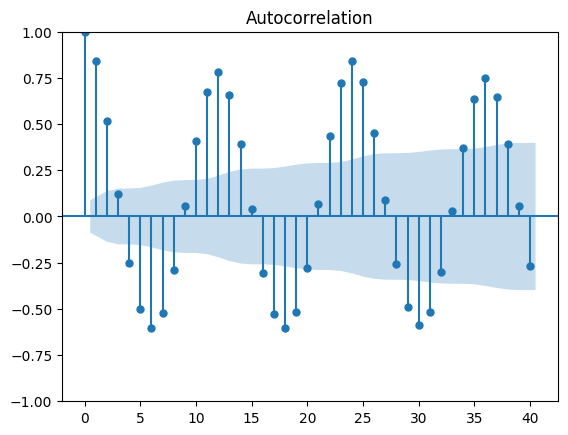

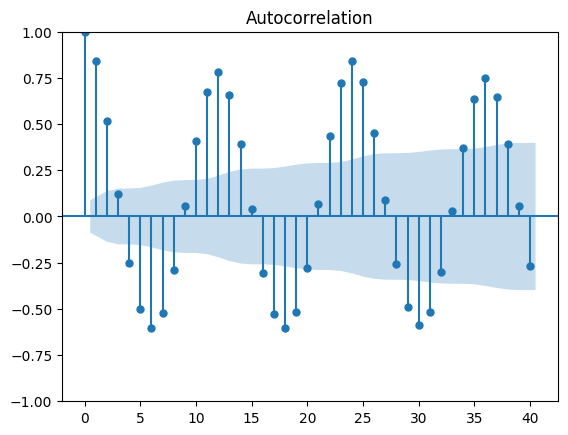

In [14]:
sm.graphics.tsa.plot_acf(data, lags=40)

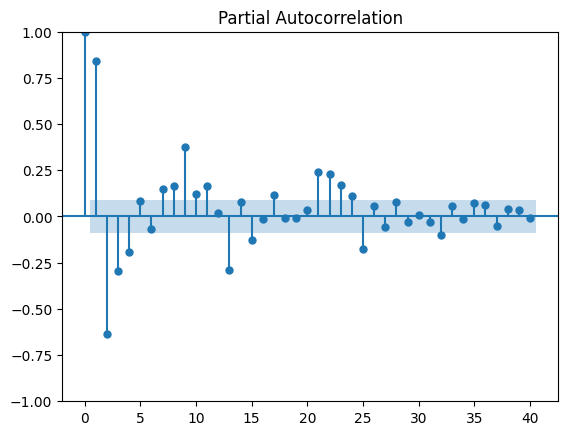

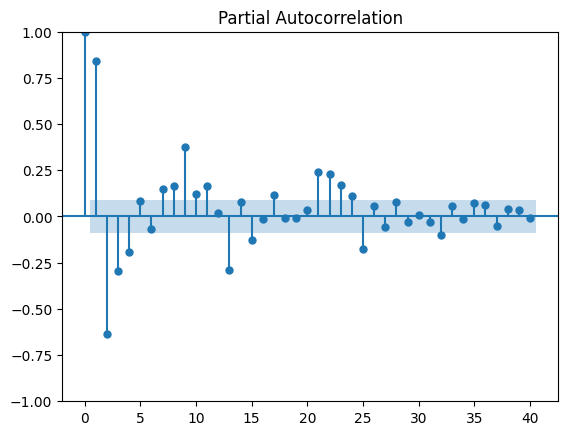

In [15]:
sm.graphics.tsa.plot_pacf(data,alpha=0.05, lags=40)

In [16]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import mean_squared_error

# Lissage simple

smoothed error: 116204.9889455045
forecast error: 126311.73389592567


<Axes: >

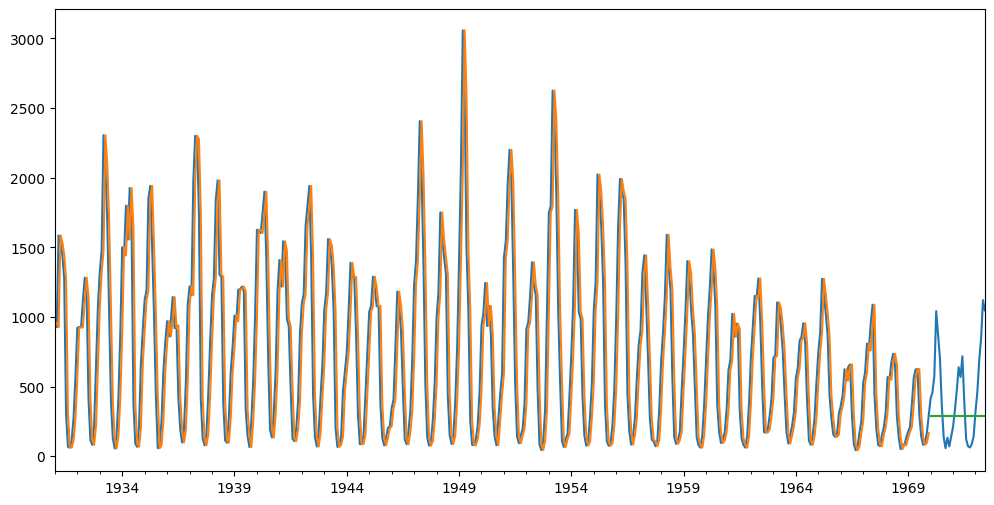

In [17]:
model = SimpleExpSmoothing(data[:"1969"])
fit = model.fit()
smoothed = fit.fittedvalues
forecast = fit.forecast(30)

print("smoothed error:",mean_squared_error(data[:"1969"], smoothed))
print("forecast error:",mean_squared_error(data["1970":], forecast))
plt.figure(figsize=(12, 6))
data.plot()
smoothed.plot()
forecast.plot()

# Lisssage double

smoothed error: 108828.99248012
forecast error: 3126824.237933367


<Axes: >

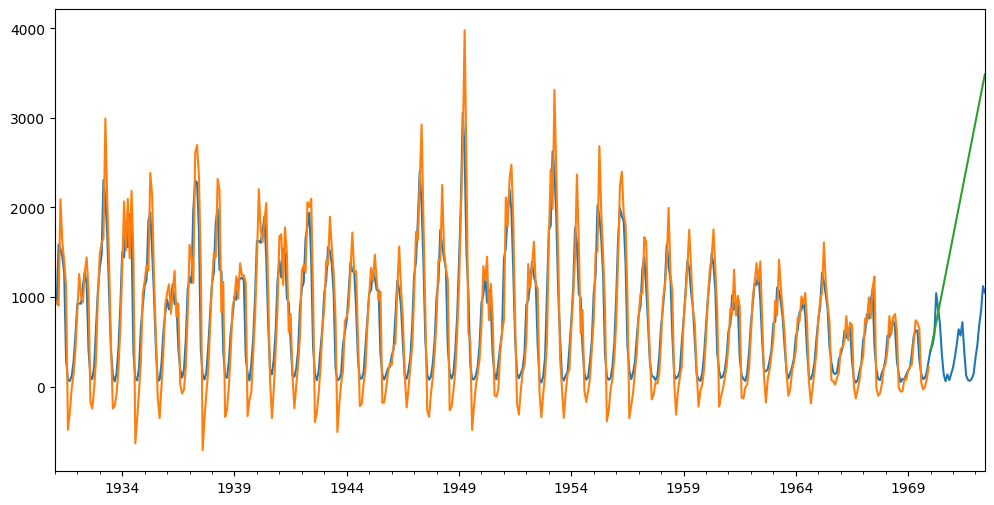

In [18]:
model = Holt(data[:"1969"])
fit = model.fit()
smoothed = fit.fittedvalues
forecast = fit.forecast(30)

print("smoothed error:",mean_squared_error(data[:"1969"], smoothed))
print("forecast error:",mean_squared_error(data["1970":], forecast))
plt.figure(figsize=(12, 6))
data.plot()
smoothed.plot()
forecast.plot()

# Lissage Triple

smoothed error: 24961.582326694417
forecast error: 45622.77969939287


<Axes: >

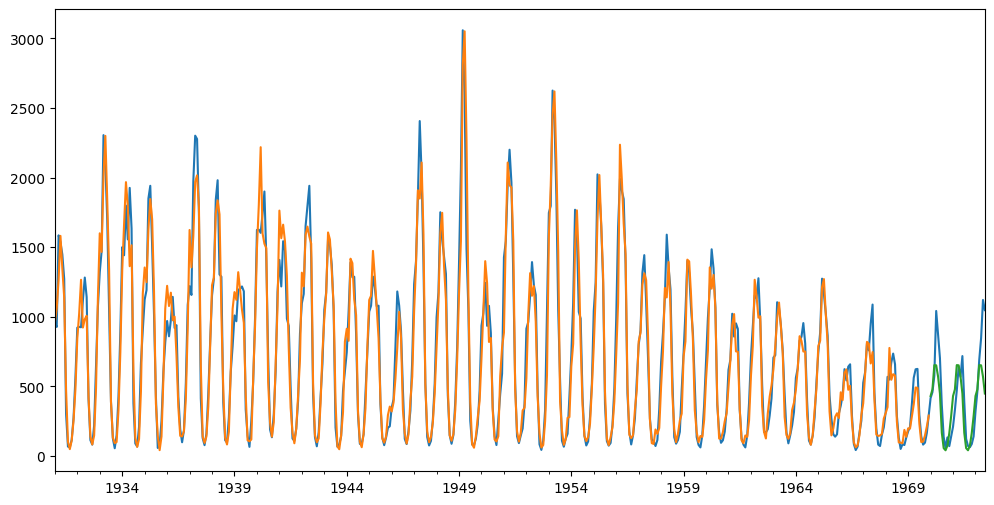

In [19]:
model = ExponentialSmoothing(data[:"1969"], seasonal='mul', seasonal_periods=12)
fit = model.fit()
smoothed = fit.fittedvalues
forecast = fit.forecast(30)

print("smoothed error:",mean_squared_error(data[:"1969"], smoothed))
print("forecast error:",mean_squared_error(data["1970":], forecast))
plt.figure(figsize=(12, 6))
data.plot()
smoothed.plot()
forecast.plot()